,voxel_nbins,Gaussian mean,Mean uncertainty,Gaussian sigma,Sigma uncertainty,success
0,8,0.60000,0.000386,0.019507,0.000273,True
1,10,0.60000,0.000376,0.026600,0.000266,True
2,15,0.60000,0.000355,0.046022,0.000251,True
3,20,0.60000,0.000345,0.068872,0.000245,True
4,25,0.59999,0.000338,0.094012,0.000241,True


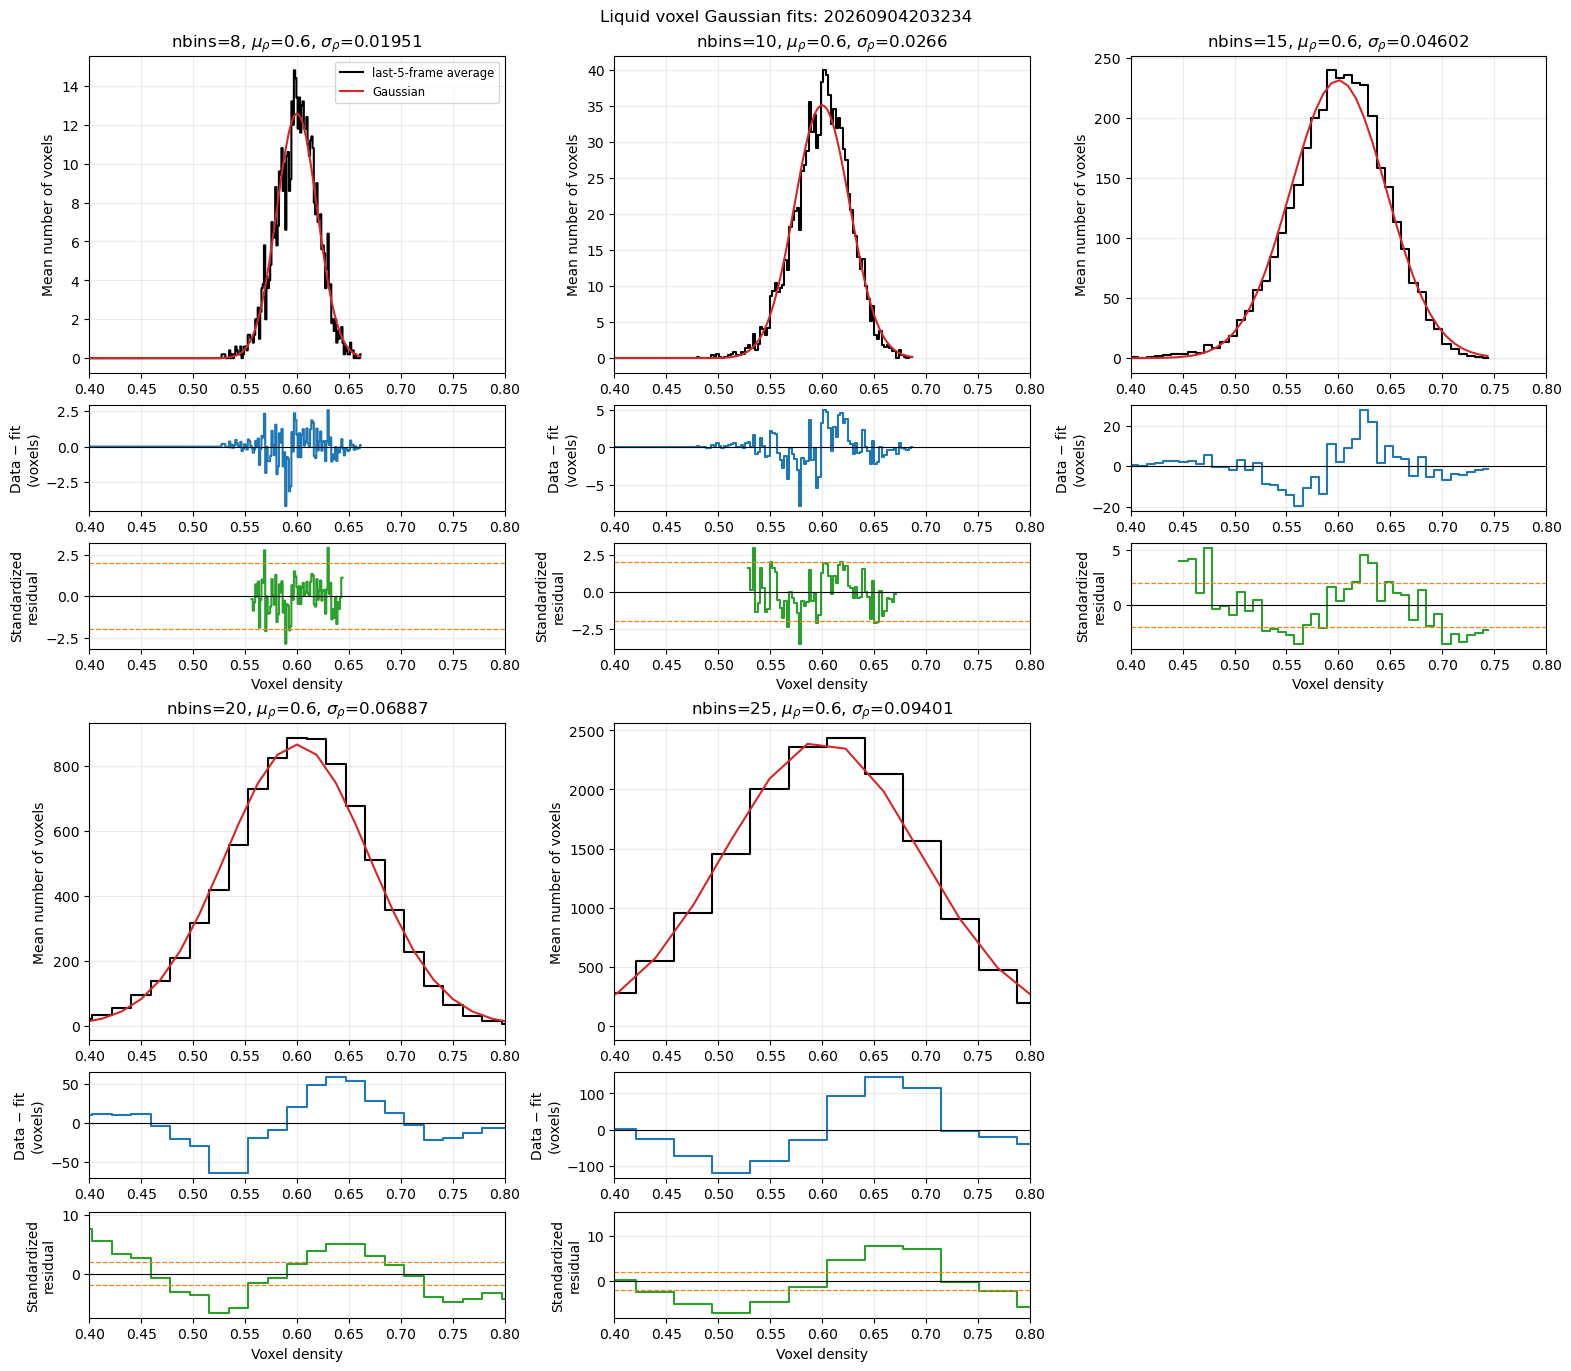

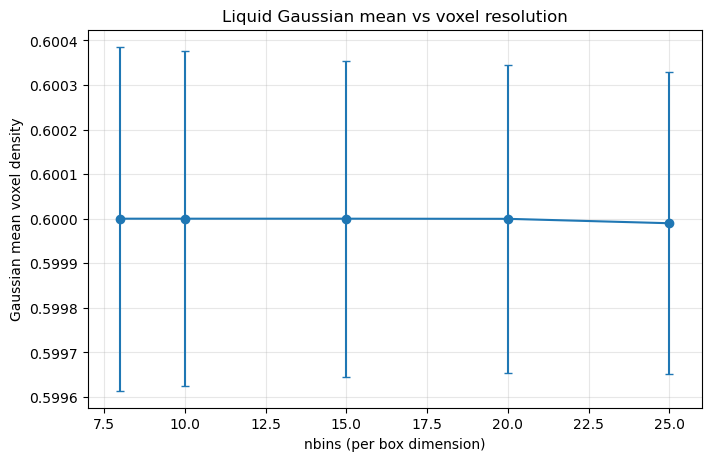

In [1]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from md_Helpers import (
    ProjectPaths,
    SQLiteRunDatabase,
    cavitation_dataframe,
    thermalization_dataframe,
    fit_liquid_nbins,
)

# Reload the updated plotting helper without restarting the kernel.
import md_Helpers.nbins_tuning as nbins_tuning
importlib.reload(nbins_tuning)

plot_liquid_nbins_gaussians = (
    nbins_tuning.plot_liquid_nbins_gaussians
)
plot_liquid_gaussian_mean_vs_nbins = (
    nbins_tuning.plot_liquid_gaussian_mean_vs_nbins
)


RUN_ID = "20260904203234"
NBINS = [8, 10, 15, 20, 25]
DENSITY_XLIM = (0.4, 0.8)


paths = ProjectPaths()
database = SQLiteRunDatabase(paths.database)
database.initialize()

state = pd.concat(
    [
        thermalization_dataframe(
            database,
            Run_ID=RUN_ID,
        ),
        cavitation_dataframe(
            database,
            Run_ID=RUN_ID,
        ),
    ],
    ignore_index=True,
).drop_duplicates(subset="Run_ID")

if len(state) != 1:
    raise ValueError(
        f"Expected one row for {RUN_ID}, found {len(state)}"
    )


fits = fit_liquid_nbins(
    state,
    nbins_values=NBINS,
    project_paths=paths,
)


# Histogram, Gaussian fit, raw residual, and standardized residual.
shape_figure, shape_axes = (
    plot_liquid_nbins_gaussians(fits)
)

# Apply the density limits to all three rows.
for axis in shape_axes.ravel():
    if axis.get_visible():
        axis.set_xlim(*DENSITY_XLIM)


# Gaussian mean density versus nbins.
mean_figure, mean_axis = (
    plot_liquid_gaussian_mean_vs_nbins(fits)
)

mean_axis.set_xlim(
    min(NBINS) - 1,
    max(NBINS) + 1,
)


display(
    fits[
        [
            "voxel_nbins",
            "gaussian_mean_density",
            "gaussian_mean_density_unc",
            "gaussian_sigma_density",
            "gaussian_sigma_density_unc",
            "success",
        ]
    ].rename(
        columns={
            "gaussian_mean_density": "Gaussian mean",
            "gaussian_mean_density_unc": "Mean uncertainty",
            "gaussian_sigma_density": "Gaussian sigma",
            "gaussian_sigma_density_unc": "Sigma uncertainty",
        }
    )
)

plt.show()

,voxel_nbins,Location ξ,Scale ω,Skewness α,Distribution mean,Mean uncertainty,ΔAIC (skew − Gaussian),success
0,8,0.615120,0.024681,-1.198311,0.600001,0.000386,-14.736199,True
1,10,0.622651,0.034938,-1.397343,0.599982,0.000376,-62.396730,True
2,15,0.641078,0.061688,-1.520675,0.599953,0.000354,-299.693770,True
3,20,0.659243,0.090846,-1.422153,0.599949,0.000345,-547.666732,True
4,25,0.675963,0.120866,-1.279700,0.599975,0.000338,-679.408843,True


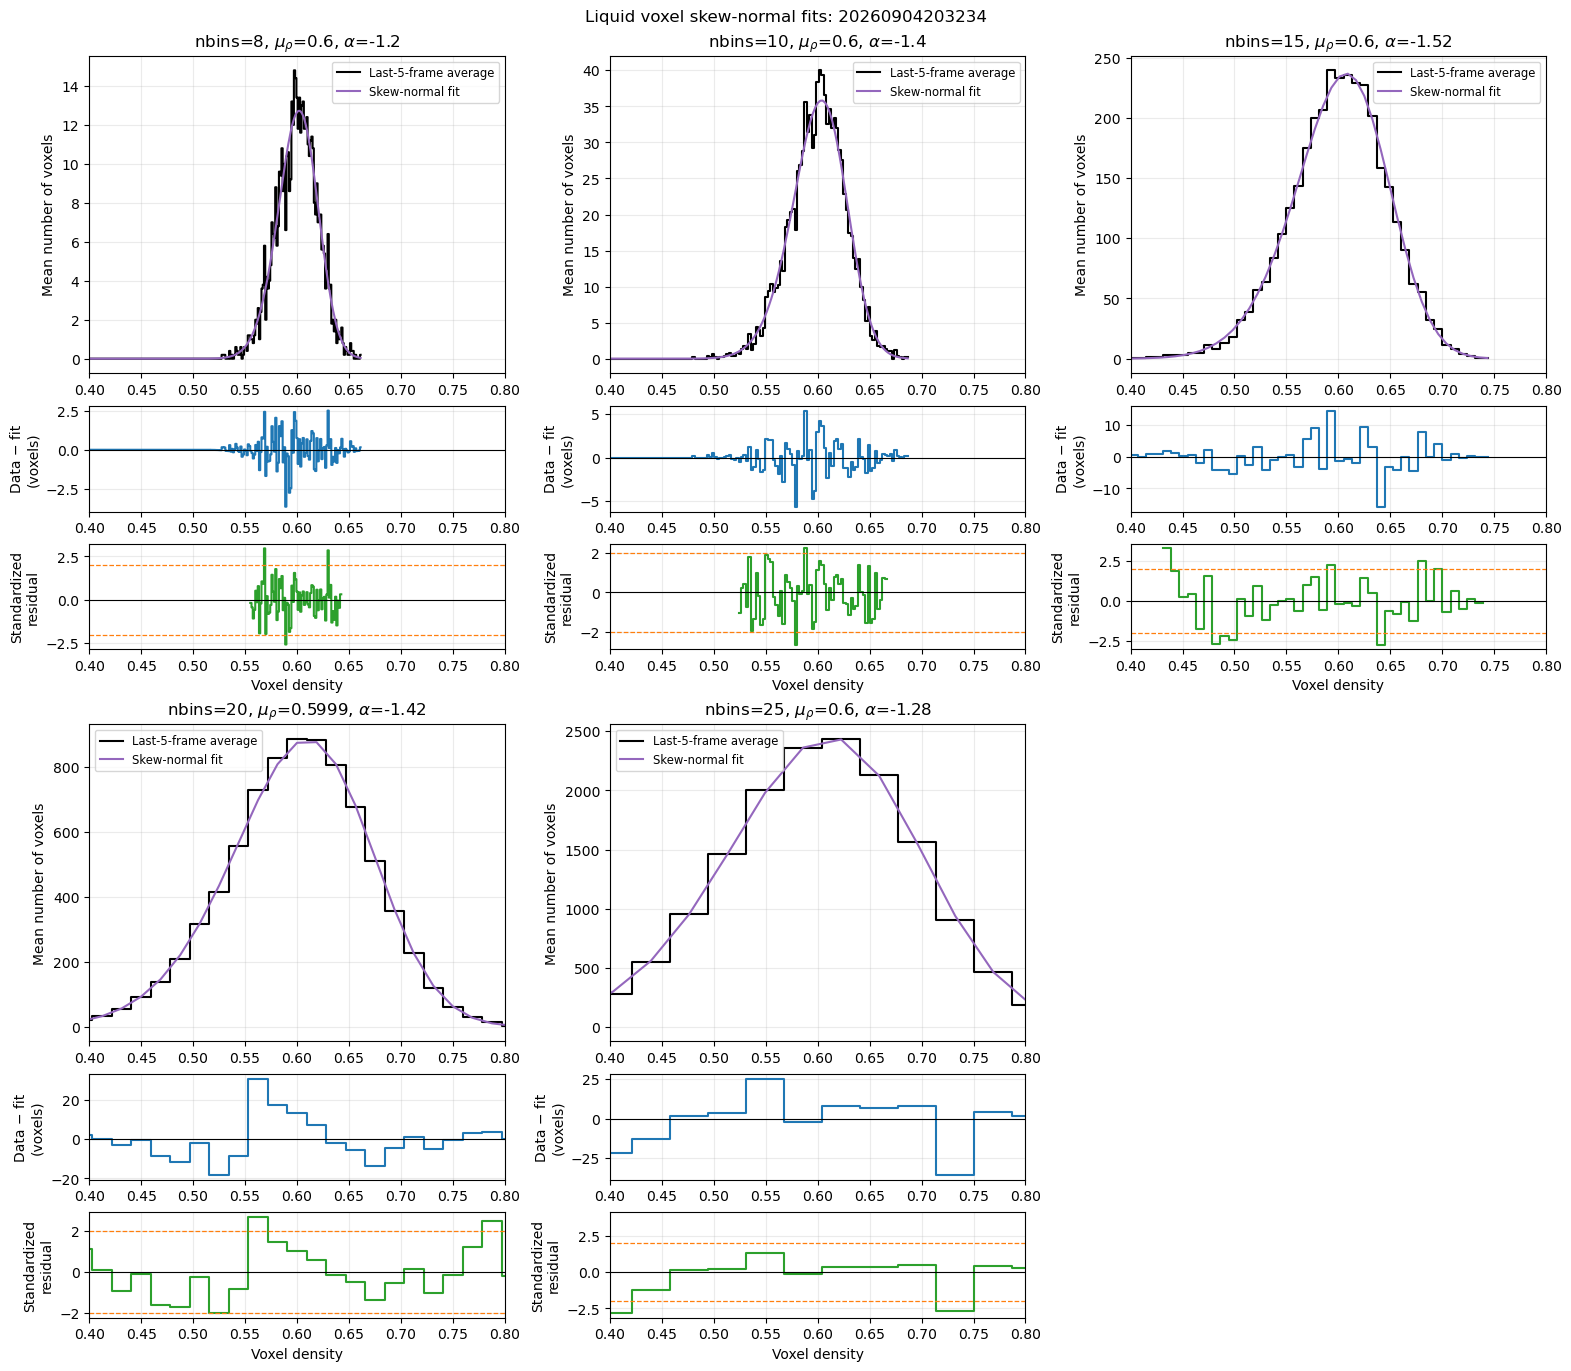

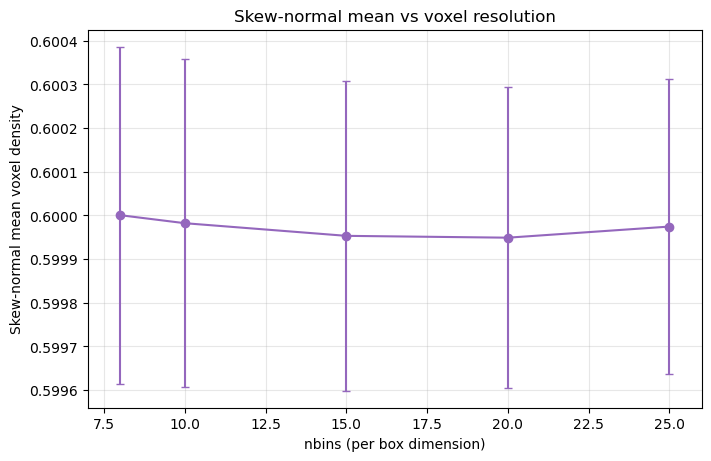

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import skewnorm
from IPython.display import display


def finite_difference_hessian(function, parameters, relative_step=1e-4):
    parameters = np.asarray(parameters, dtype=float)
    steps = relative_step * np.maximum(1.0, np.abs(parameters))
    hessian = np.zeros((len(parameters), len(parameters)))
    center = float(function(parameters))

    for i in range(len(parameters)):
        step_i = np.zeros_like(parameters)
        step_i[i] = steps[i]

        hessian[i, i] = (
            function(parameters + step_i)
            - 2.0 * center
            + function(parameters - step_i)
        ) / steps[i] ** 2

        for j in range(i + 1, len(parameters)):
            step_j = np.zeros_like(parameters)
            step_j[j] = steps[j]

            value = (
                function(parameters + step_i + step_j)
                - function(parameters + step_i - step_j)
                - function(parameters - step_i + step_j)
                + function(parameters - step_i - step_j)
            ) / (4.0 * steps[i] * steps[j])

            hessian[i, j] = value
            hessian[j, i] = value

    return 0.5 * (hessian + hessian.T)


def fit_skew_normal_to_row(row):
    count_axis = np.asarray(row["count_axis"], dtype=float)
    observed_average = np.asarray(row["observed_counts"], dtype=float)

    frames_used = int(row["frames_used"])
    nbins = int(row["voxel_nbins"])
    voxels_per_frame = nbins**3

    # Total histogram used by the likelihood.
    observed_total = observed_average * frames_used

    maximum_count = max(2.0, float(count_axis[-1]))
    normal_mean = float(row["gaussian_mean"])
    normal_sigma = max(0.05, float(row["gaussian_sigma"]))

    def probabilities(location, scale, alpha):
        lower = count_axis - 0.5
        lower[count_axis == 0] = -np.inf
        upper = count_axis + 0.5

        return (
            skewnorm.cdf(
                upper,
                a=alpha,
                loc=location,
                scale=scale,
            )
            - skewnorm.cdf(
                lower,
                a=alpha,
                loc=location,
                scale=scale,
            )
        )

    # Optimizer parameters:
    # [location, log(scale), alpha]
    def objective(parameters):
        location = parameters[0]
        scale = np.exp(parameters[1])
        alpha = parameters[2]

        probability = probabilities(location, scale, alpha)

        return float(
            -np.dot(
                observed_total,
                np.log(np.clip(probability, 1e-300, None)),
            )
        )

    # Try several initial skewness values.
    candidates = []

    for alpha_start in [-4.0, -2.0, -0.25, 0.25, 2.0, 4.0]:
        delta_start = alpha_start / np.sqrt(1.0 + alpha_start**2)

        location_start = (
            normal_mean
            - normal_sigma
            * delta_start
            * np.sqrt(2.0 / np.pi)
        )

        result = minimize(
            objective,
            x0=[
                location_start,
                np.log(normal_sigma),
                alpha_start,
            ],
            method="L-BFGS-B",
            bounds=[
                (-maximum_count, 2.0 * maximum_count),
                (np.log(0.05), np.log(maximum_count)),
                (-20.0, 20.0),
            ],
            options={"maxiter": 1000},
        )

        candidates.append(result)

    optimum = min(candidates, key=lambda result: result.fun)

    location = float(optimum.x[0])
    scale = float(np.exp(optimum.x[1]))
    alpha = float(optimum.x[2])

    fitted_probability = probabilities(
        location,
        scale,
        alpha,
    )

    fitted_counts = (
        voxels_per_frame * fitted_probability
    )

    raw_residual = observed_average - fitted_counts

    # Variance of the average histogram count under an approximate
    # multinomial model.
    residual_variance = (
        voxels_per_frame
        * fitted_probability
        * (1.0 - fitted_probability)
        / frames_used
    )

    standardized_residual = np.full_like(
        raw_residual,
        np.nan,
        dtype=float,
    )

    # Exclude bins with fewer than five expected observations across
    # all five frames.
    expected_total = fitted_counts * frames_used
    valid = (
        (expected_total >= 5.0)
        & np.isfinite(residual_variance)
        & (residual_variance > 0.0)
    )

    standardized_residual[valid] = (
        raw_residual[valid]
        / np.sqrt(residual_variance[valid])
    )

    delta = alpha / np.sqrt(1.0 + alpha**2)

    distribution_mean = (
        location
        + scale * delta * np.sqrt(2.0 / np.pi)
    )

    distribution_variance = scale**2 * (
        1.0 - 2.0 * delta**2 / np.pi
    )
    distribution_sigma = np.sqrt(distribution_variance)

    # Estimate parameter covariance.
    hessian = finite_difference_hessian(
        objective,
        optimum.x,
    )

    try:
        covariance = np.linalg.inv(hessian)
        covariance_method = "inverse Hessian"
    except np.linalg.LinAlgError:
        covariance = np.linalg.pinv(hessian)
        covariance_method = "pseudo-inverse Hessian"

    covariance = 0.5 * (covariance + covariance.T)

    # Gradient of the skew-normal mean with respect to:
    # [location, log(scale), alpha]
    mean_gradient = np.array(
        [
            1.0,
            scale * delta * np.sqrt(2.0 / np.pi),
            scale
            * np.sqrt(2.0 / np.pi)
            / (1.0 + alpha**2) ** 1.5,
        ]
    )

    mean_variance = float(
        mean_gradient @ covariance @ mean_gradient
    )

    mean_uncertainty = (
        np.sqrt(mean_variance)
        if np.isfinite(mean_variance)
        and mean_variance >= 0
        else np.nan
    )

    voxel_volume = float(row["voxel_volume"])

    gaussian_aic = (
        2 * 2
        - 2 * float(row["log_likelihood"])
    )
    skew_aic = (
        2 * 3
        + 2 * float(optimum.fun)
    )

    return {
        "Run_ID": row["Run_ID"],
        "voxel_nbins": nbins,
        "frames_used": frames_used,
        "voxels_per_frame": voxels_per_frame,
        "density_axis": np.asarray(row["density_axis"]),
        "observed_counts": observed_average,
        "skew_counts": fitted_counts,
        "raw_residual": raw_residual,
        "standardized_residual": standardized_residual,
        "expected_total": expected_total,

        # Three fitted parameters
        "skew_location": location,
        "skew_scale": scale,
        "skew_alpha": alpha,

        # Distribution moments
        "skew_mean": distribution_mean,
        "skew_sigma": distribution_sigma,
        "skew_mean_unc": mean_uncertainty,

        # Density-axis values
        "skew_location_density": location / voxel_volume,
        "skew_scale_density": scale / voxel_volume,
        "skew_mean_density": distribution_mean / voxel_volume,
        "skew_mean_density_unc": (
            mean_uncertainty / voxel_volume
        ),
        "skew_sigma_density": (
            distribution_sigma / voxel_volume
        ),

        "log_likelihood": -float(optimum.fun),
        "gaussian_AIC": gaussian_aic,
        "skew_AIC": skew_aic,
        "delta_AIC": skew_aic - gaussian_aic,
        "success": bool(optimum.success),
        "message": str(optimum.message),
        "covariance_method": covariance_method,
    }


# ---------------------------------------------------------------
# Fit the skew-normal distribution for every selected nbins.
# ---------------------------------------------------------------

skew_fits = pd.DataFrame(
    [
        fit_skew_normal_to_row(row)
        for _, row in (
            fits.sort_values("voxel_nbins").iterrows()
        )
    ]
)


# ---------------------------------------------------------------
# Plot:
#   1. Histogram and fit
#   2. Raw residual
#   3. Standardized residual
# ---------------------------------------------------------------

number_of_plots = len(skew_fits)
columns = min(3, number_of_plots)
panel_rows = int(np.ceil(number_of_plots / columns))

skew_shape_figure, skew_shape_axes = plt.subplots(
    3 * panel_rows,
    columns,
    figsize=(5.2 * columns, 6.8 * panel_rows),
    squeeze=False,
    constrained_layout=True,
    gridspec_kw={
        "height_ratios": [
            value
            for _ in range(panel_rows)
            for value in (3, 1, 1)
        ]
    },
)

for panel_index, (_, fit) in enumerate(
    skew_fits.iterrows()
):
    panel_row, column = divmod(
        panel_index,
        columns,
    )

    fit_axis = skew_shape_axes[
        3 * panel_row,
        column,
    ]
    raw_residual_axis = skew_shape_axes[
        3 * panel_row + 1,
        column,
    ]
    standardized_axis = skew_shape_axes[
        3 * panel_row + 2,
        column,
    ]

    density = np.asarray(fit["density_axis"])
    observed = np.asarray(fit["observed_counts"])
    predicted = np.asarray(fit["skew_counts"])
    raw_residual = np.asarray(fit["raw_residual"])
    standardized = np.asarray(
        fit["standardized_residual"]
    )

    # Histogram and fit
    fit_axis.step(
        density,
        observed,
        where="mid",
        color="black",
        label="Last-5-frame average",
    )
    fit_axis.plot(
        density,
        predicted,
        color="tab:purple",
        label="Skew-normal fit",
    )
    fit_axis.set(
        title=(
            f"nbins={int(fit['voxel_nbins'])}, "
            rf"$\mu_\rho$="
            f"{fit['skew_mean_density']:.4g}, "
            rf"$\alpha$="
            f"{fit['skew_alpha']:.3g}"
        ),
        ylabel="Mean number of voxels",
    )
    fit_axis.grid(alpha=0.25)
    fit_axis.legend(fontsize="small")

    # Raw residual
    raw_residual_axis.step(
        density,
        raw_residual,
        where="mid",
        color="tab:blue",
    )
    raw_residual_axis.axhline(
        0.0,
        color="black",
        linewidth=0.8,
    )
    raw_residual_axis.set(
        ylabel="Data − fit\n(voxels)",
    )
    raw_residual_axis.grid(alpha=0.25)

    # Standardized residual
    standardized_axis.step(
        density,
        standardized,
        where="mid",
        color="tab:green",
    )
    standardized_axis.axhline(
        0.0,
        color="black",
        linewidth=0.8,
    )
    standardized_axis.axhline(
        2.0,
        color="tab:orange",
        linestyle="--",
        linewidth=0.9,
    )
    standardized_axis.axhline(
        -2.0,
        color="tab:orange",
        linestyle="--",
        linewidth=0.9,
    )
    standardized_axis.set(
        xlabel="Voxel density",
        ylabel="Standardized\nresidual",
    )
    standardized_axis.grid(alpha=0.25)

    # Apply the same density limits to all three rows.
    fit_axis.set_xlim(*DENSITY_XLIM)
    raw_residual_axis.set_xlim(*DENSITY_XLIM)
    standardized_axis.set_xlim(*DENSITY_XLIM)


# Hide unused columns/panels.
for panel_index in range(
    number_of_plots,
    panel_rows * columns,
):
    panel_row, column = divmod(
        panel_index,
        columns,
    )

    skew_shape_axes[
        3 * panel_row,
        column,
    ].set_visible(False)

    skew_shape_axes[
        3 * panel_row + 1,
        column,
    ].set_visible(False)

    skew_shape_axes[
        3 * panel_row + 2,
        column,
    ].set_visible(False)


skew_shape_figure.suptitle(
    f"Liquid voxel skew-normal fits: {RUN_ID}"
)


# ---------------------------------------------------------------
# Skew-normal mean density versus nbins.
# ---------------------------------------------------------------

skew_mean_figure, skew_mean_axis = plt.subplots(
    figsize=(7, 4.5),
    constrained_layout=True,
)

skew_mean_axis.errorbar(
    skew_fits["voxel_nbins"],
    skew_fits["skew_mean_density"],
    yerr=skew_fits["skew_mean_density_unc"],
    marker="o",
    capsize=3,
    color="tab:purple",
)

skew_mean_axis.set(
    xlabel="nbins (per box dimension)",
    ylabel="Skew-normal mean voxel density",
    title="Skew-normal mean vs voxel resolution",
)

skew_mean_axis.set_xlim(
    min(NBINS) - 1,
    max(NBINS) + 1,
)
skew_mean_axis.grid(alpha=0.3)


# ---------------------------------------------------------------
# Display fitted parameters and model comparison.
# ---------------------------------------------------------------

display(
    skew_fits[
        [
            "voxel_nbins",
            "skew_location_density",
            "skew_scale_density",
            "skew_alpha",
            "skew_mean_density",
            "skew_mean_density_unc",
            "delta_AIC",
            "success",
        ]
    ].rename(
        columns={
            "skew_location_density": "Location ξ",
            "skew_scale_density": "Scale ω",
            "skew_alpha": "Skewness α",
            "skew_mean_density": "Distribution mean",
            "skew_mean_density_unc": "Mean uncertainty",
            "delta_AIC": "ΔAIC (skew − Gaussian)",
        }
    )
)

plt.show()